# MO coefficients discrepancies: He/cc-pvtz

**NOTE: THIS NOTEBOOK IS OBSOLETE. APPROPRIATE FIXES WERE PERFORMED AND DISCUSSION CORRESPONDS TO PREVIOUS ERRONEOUS IMPLEMENTATION VERSION.** 
---

In this noteboo I'll try to locate the discrepancies between my SCF implementation and the PySCF implementation, to try to understand the differences in MP2 energies computed:

- As a first example, I'll calculate the MP2 energy using my MO coefficients and the ones obtained by pyscf to check that the MP2 internal logic is actually correct. 
- After that I'll compare the MO coefficients and plot the relevant orbitals to see the discrepancies. 
- Finally I'll propose the possible fixes and get working on them. 

In [1]:
# imports
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_mo_analysis, plot_map
import matplotlib.pyplot as plt

from pathlib import Path

from pyscf.tools import molden

# MP2 Energies
First we will start by defining the system:

In [2]:
full_basis = gto.basis.load("cc-pVTZ", "He")

pyscf_args = {"atom": "He 0 0 0", "spin": 0, "charge": 0, "basis": {"He": full_basis}}

And calculate with pyscf the SCF and MP2 energies:

In [3]:
mol = gto.M(**pyscf_args)
mf = scf.RHF(mol)
E_SCF_pyscf = mf.kernel()
mymp = mp.RMP2(mf).run()
E_mp2_pyscf = mymp.e_tot
E_corr_pyscf = mymp.e_corr

converged SCF energy = -2.86115334478442
E(RMP2) = -2.89429090653932  E_corr = -0.0331375617548948
E(SCS-RMP2) = -2.9009184188903  E_corr = -0.0397650741058737


Now I will calculate the same with the implementation:

In [4]:
ctx = RHF_context_from_pyscf(**pyscf_args)
res = CS_RHF(ctx)
E_SCF_impl = res.E_RHF
print(f"SCF energy = {E_SCF_impl.real}")
mp2_res = CS_MP2(res)
E_mp2_impl = mp2_res.E_MP2.real
E_corr_impl = mp2_res.E_corr.real
print(f"E(RMP2) = {E_mp2_impl}, E_corr {E_corr_impl}")

SCF energy = -2.861153344784422
E(RMP2) = -2.8942909065417695, E_corr -0.03313756175734728


And now we compare results:

In [5]:
# Difference in SCF energies
E_SCF_diff = E_SCF_impl.real - E_SCF_pyscf
print(f"Difference in SCF energies: {E_SCF_diff} Hartree")

# differences in correlation energies
E_diff = E_corr_impl - E_corr_pyscf
print(f"\n\nDifference in correlation energies: {E_diff} Hartree")

Difference in SCF energies: -8.881784197001252e-16 Hartree


Difference in correlation energies: -2.4525173558664903e-12 Hartree


We can see that the SCF energy is exactly the same. 

However the MP2 erergy error is not negligible at all. Now we will enforce Pyscf's MO coefficients onto our implementation of the MP2:

In [6]:
# enforce MO coefficients
res.R_munu = mf.mo_coeff

# Perform again the calculation
mp2_res = CS_MP2(res)
E_mp2_impl_forced = mp2_res.E_MP2.real
E_corr_impl_forced = mp2_res.E_corr.real
print(f"E(RMP2) = {E_mp2_impl_forced}, E_corr {E_corr_impl_forced}")

E(RMP2) = -2.8942909065390947, E_corr -0.03313756175467235


And compare once again:

In [7]:
# differences in correlation energies
E_diff = E_corr_impl_forced - E_corr_pyscf
print(f"Difference in correlation energies: {E_diff} Hartree")

Difference in correlation energies: 2.224123663019384e-13 Hartree


Which is basically numerical precision. Therefore we can see that the MP2 logic is correct and thus the issue must lie on the coefficients.

# MO coefficients and orbitals
First of all we will have a look at the MO coefficients obtained with each implementation. We will reset due to the cost being almost zero:

In [8]:
mol = gto.M(**pyscf_args)
mf = scf.RHF(mol)
mf2 = scf.RHF(mol)
mf2.kernel()
E_SCF_pyscf = mf.kernel()
ctx = RHF_context_from_pyscf(**pyscf_args)
res = CS_RHF(ctx)
E_SCF_impl = res.E_RHF
print(f"Implement SCF energy = {E_SCF_impl.real:.15}")

converged SCF energy = -2.86115334478442
converged SCF energy = -2.86115334478442
Implement SCF energy = -2.86115334478442


With this, we can now plot the eigenvectors and eigenvalues of both implementations:

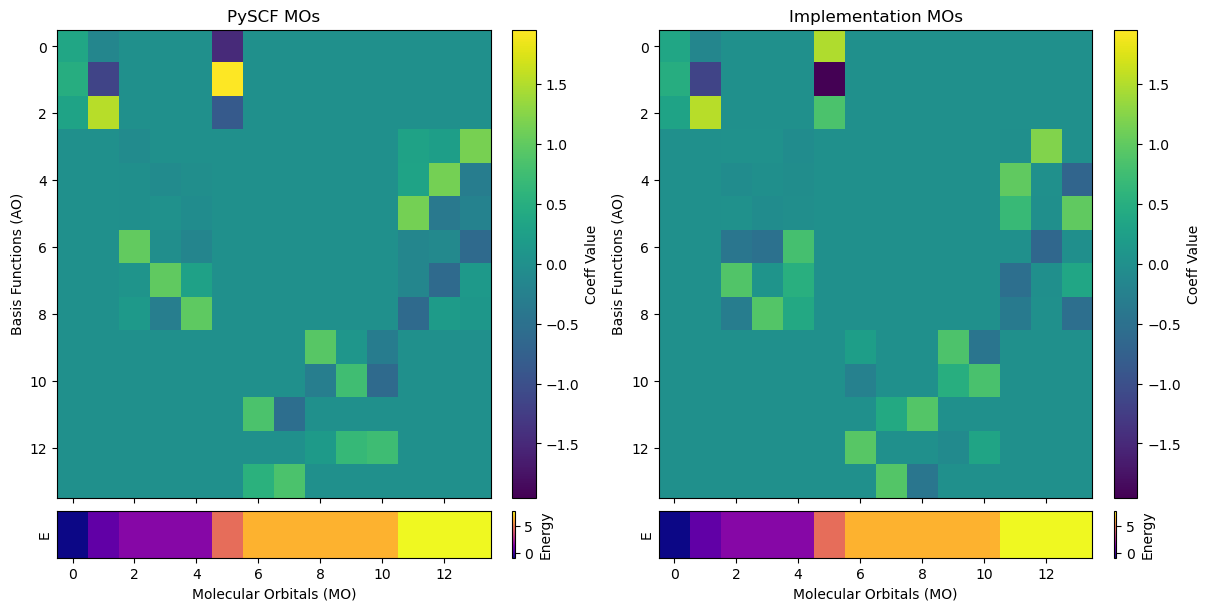

In [9]:
C_pscf = mf.mo_coeff
e_pscf = mf.mo_energy
C_impl = res.R_munu.real
e_impl = np.diag((C_impl.T @ res.F_final @ C_impl).real)

plot = plot_mo_analysis(
    C_pscf, e_pscf, C_impl, e_impl, titles=["PySCF MOs", "Implementation MOs"]
)

However, messing around, I have realized that pyscf does not always yield the same MO coefficients. In the $p$ block, sometimes solutions have a matrix shape of:

$$
\begin{pmatrix}
1 & 0.12 & -0.25 \\
-0.12 & 1 & 0.025\\
0.25 & -0.01 & 1 \\
\end{pmatrix}
$$
To which we will refer as "diagonal" MO coefficients. However, some other times it is something like:
$$
\begin{pmatrix}
1.03 & -0.12 &  0.00 \\
0.07 &  0.60 &  0.84 \\
 0.10 &  0.84 & -0.60
\end{pmatrix}
$$
---
To which we will refer as "nondiagonal" MO coefficients. So lets see the different MOs for each case:

|Orbital| Pyscf "diagonal"| Pyscf "nondiagonal"| Implementation|
|-|-|-|-|
|$2p1$|![](MO_coefficients/py_diag/2p1.png)|![](MO_coefficients/py_non_diag/2p1.png)|![](MO_coefficients/Me/2p1.png)|
|$2p2$|![](MO_coefficients/py_diag/2p2.png)|![](MO_coefficients/py_non_diag/2p2.png)|![](MO_coefficients/Me/2p2.png)|
|$2p3$|![](MO_coefficients/py_diag/2p3.png)|![](MO_coefficients/py_non_diag/2p3.png)|![](MO_coefficients/Me/2p3.png)|
|$3s1$|![](MO_coefficients/py_diag/3s1.png)|![](MO_coefficients/py_non_diag/3s1.png)|![](MO_coefficients/Me/3s1.png)|
|$4d1$|![](MO_coefficients/py_diag/4d1.png)|![](MO_coefficients/py_non_diag/4d1.png)|![](MO_coefficients/Me/4d1.png)|
|$4d2$|![](MO_coefficients/py_diag/4d2.png)|![](MO_coefficients/py_non_diag/4d2.png)|![](MO_coefficients/Me/4d2.png)|
|$4d3$|![](MO_coefficients/py_diag/4d3.png)|![](MO_coefficients/py_non_diag/4d3.png)|![](MO_coefficients/Me/4d3.png)|
|$4d4$|![](MO_coefficients/py_diag/4d4.png)|![](MO_coefficients/py_non_diag/4d4.png)|![](MO_coefficients/Me/4d4.png)|
|$4d5$|![](MO_coefficients/py_diag/4d5.png)|![](MO_coefficients/py_non_diag/4d5.png)|![](MO_coefficients/Me/4d5.png)|
|$3p1$|![](MO_coefficients/py_diag/3p1.png)|![](MO_coefficients/py_non_diag/3p1.png)|![](MO_coefficients/Me/3p1.png)|
|$3p2$|![](MO_coefficients/py_diag/3p2.png)|![](MO_coefficients/py_non_diag/3p2.png)|![](MO_coefficients/Me/3p2.png)|
|$3p3$|![](MO_coefficients/py_diag/3p3.png)|![](MO_coefficients/py_non_diag/3p3.png)|![](MO_coefficients/Me/3p3.png)|
---
From the previous table, it is possible to see the following:
- $2p$ orbitals:
    - The orbitals, albeit not being defined with the same coefficients, are the same. Their spatial configuration is exactly the same.
- $3s$ orbitals:
    - They are defined in the exact same way and the molecular coefficients are the same. 
- $4d$ orbitals: 
    - The pyscf orbitals in both cases, even though they yield the same correlation energies of $-0.0331375617548947$ in both cases, but the implementation difers in $-0.00035$ Hartree.
    - In the "diagonal" orbitals, there are 3 well defined d orbitals of the type $d_{xy}$, $d_{x^2-y^2}$, $d_{yz}$ or $d_{xz}$ with the two expected nodal planes, while there is one without the second nodal plane well defined. Finally there is a orbital of type $d_{z^2}$, but it is not orientated in the $z$ direction and is not perfectly radial symmetric. 
    - In the case of the "nondiagonal" orbitals, all nodal planes in the $d_{xy}$, $d_{x^2-y^2}$, $d_{yz}$ or $d_{xz}$ orbitals are well defined, but the $d_{z^2}$ orbital is again not oriented in the $z$ direction, but is better defined radially.
    - in the implementation case, only one $d_{xy}$, $d_{x^2-y^2}$, $d_{yz}$ or $d_{xz}$ orbital is well defined, while the rest are a mix of different d orbitals. The $d_{z^2}$ orbital is aligned with the $z$ direction and is radially symmetric.
- $3p$ orbitals:
    - In the "diagonal" and "nondiagonal" case, all $p$ orbitals are mixed, as there is not a pure $3p_x$, $3p_y$ or $3p_z$ orbital.
    - However in the implementation case, the $3p$ orbitals are well separated between a mix of $x$ and $y$ directions independent of the $z$ direction.

---

## Continuation
Therefore, with this in mind, the following questions may be asked:
- If the $2p$ are well defined, what if we limit ourselves to those? Is the correlation energy correct?
- If we restrict us only to $s$ and $p$ functions, is there some error induced by the $d$ shell?
- Can increasing the basis size improve the correlation energy?
- Is occupation relevant in these cases? This comes from previous calculations in other systems that show an error decrease for larger noble gases (with exceptions). This is replicated at the end of the notebook. 

# Truncating the basis
## Restricting to $n=2$
First we can check if using only $1s$, $2s$, and $2p$ functions yields the correct correlation energy. For this we will check with the cc-pVDZ and the 6-311g. We will define first a helpful function:

In [10]:
def test_mp2_with_basis(sp_only_basis):
    pyscf_args = {
        "atom": "He 0 0 0",
        "spin": 0,
        "charge": 0,
        "basis": {"He": sp_only_basis},
    }

    mol = gto.M(**pyscf_args)
    mf = scf.RHF(mol)
    E_SCF_pyscf = mf.kernel()
    mymp = mp.RMP2(mf).run()
    E_mp2_pyscf = mymp.e_tot
    E_corr_pyscf = mymp.e_corr

    # implementation
    ctx = RHF_context_from_pyscf(**pyscf_args)
    res = CS_RHF(ctx)
    E_SCF_impl = res.E_RHF
    mp2_res = CS_MP2(res)
    E_mp2_impl = mp2_res.E_MP2.real
    E_corr_impl = mp2_res.E_corr.real

    # Difference in SCF energies
    E_SCF_diff = E_SCF_impl.real - E_SCF_pyscf
    print(f"\n\nDifference in SCF energies: {E_SCF_diff} Hartree")

    # differences in correlation energies
    E_diff = E_corr_impl - E_corr_pyscf
    print(f"Difference in correlation energies: {E_diff} Hartree")

    return res

### cc-pVDZ Basis

In [11]:
# keep only s and p
full_basis = gto.basis.load("cc-pVDZ", "He")
sp_only_basis = [b for b in full_basis if b[0] <= 1]

_ = test_mp2_with_basis(sp_only_basis)

converged SCF energy = -2.85516047724274
E(RMP2) = -2.88098881679413  E_corr = -0.025828339551385
E(SCS-RMP2) = -2.8861544847044  E_corr = -0.030994007461662


Difference in SCF energies: 4.440892098500626e-16 Hartree
Difference in correlation energies: 8.614636781700824e-15 Hartree


Which is correct. 

### 6-311 basis

In [12]:
# keep only s and p
full_basis = gto.basis.load("6-311g", "He")
sp_only_basis = [b for b in full_basis if b[0] <= 1]

_ = test_mp2_with_basis(sp_only_basis)

converged SCF energy = -2.85989542456921
E(RMP2) = -2.87280201766974  E_corr = -0.0129065931005366
E(SCS-RMP2) = -2.87538333628985  E_corr = -0.0154879117206439


Difference in SCF energies: -8.881784197001252e-16 Hartree
Difference in correlation energies: -1.6930536833603682e-12 Hartree


Which is also correct. 

---

### Conclusion on restricting $n$
**The $1s$, $2s$, and $2p$ molecular orbitals are well defined and yield the correct correlation energy. Therefore the error must be with higher angular momentum or higher $n$ quantum number.**

---

## Increasing $n$ but restricting $l$
Now we will check if increasing the basis size but restricting to $s$ and $p$ functions only yields better results. For this we will use the cc-pVT, cc-pVQZ and cc-pV5Z bases:

In [13]:
full_basis = gto.basis.load("aug-cc-pVTZ", "He")
sp_only_basis = [b for b in full_basis if b[0] <= 1]

print("######## sp cc-pvtz ########\n")

_ = test_mp2_with_basis(sp_only_basis)

full_basis = gto.basis.load("aug-cc-pVQZ", "He")
sp_only_basis = [b for b in full_basis if b[0] <= 1]

print("\n\n######## sp cc-pvqz ########\n")

_ = test_mp2_with_basis(sp_only_basis)

full_basis = gto.basis.load("aug-cc-pV5Z", "He")
sp_only_basis = [b for b in full_basis if b[0] <= 1]

print("\n\n######## sp cc-pv5z ########\n")
a = test_mp2_with_basis(sp_only_basis)

######## sp cc-pvtz ########

converged SCF energy = -2.86118342611556
E(RMP2) = -2.89229491597349  E_corr = -0.0311114898579249
E(SCS-RMP2) = -2.89851721394507  E_corr = -0.0373337878295098


Difference in SCF energies: -8.881784197001252e-16 Hartree
Difference in correlation energies: -2.7130288640653255e-10 Hartree


######## sp cc-pvqz ########

converged SCF energy = -2.86152199563245
E(RMP2) = -2.89358494401988  E_corr = -0.032062948387433
E(SCS-RMP2) = -2.89999753369737  E_corr = -0.0384755380649196


Difference in SCF energies: -1.2878587085651816e-14 Hartree
Difference in correlation energies: 4.705209138977651e-11 Hartree


######## sp cc-pv5z ########

converged SCF energy = -2.86162692924581
E(RMP2) = -2.89397545988432  E_corr = -0.0323485306385159
E(SCS-RMP2) = -2.90044516601203  E_corr = -0.038818236766219


Difference in SCF energies: -7.549516567451064e-15 Hartree
Difference in correlation energies: 4.1234730907557804e-11 Hartree


And we can see here that the inclusion of higher $n$ functions with $p$ is a source of error. Lets test with only $s$ functions:

In [14]:
full_basis = gto.basis.load("aug-cc-pVTZ", "He")
sp_only_basis = [b for b in full_basis if b[0] < 1]

print("######## spcc-pvtz ########\n")

_ = test_mp2_with_basis(sp_only_basis)

full_basis = gto.basis.load("aug-cc-pVQZ", "He")
sp_only_basis = [b for b in full_basis if b[0] < 1]

print("\n\n######## s cc-pvqz ########\n")

_ = test_mp2_with_basis(sp_only_basis)

full_basis = gto.basis.load("aug-cc-pV5Z", "He")
sp_only_basis = [b for b in full_basis if b[0] < 1]

print("\n\n######## spcc-pv5z ########\n")
a = test_mp2_with_basis(sp_only_basis)

######## spcc-pvtz ########

converged SCF energy = -2.86118342611556
E(RMP2) = -2.87408173462556  E_corr = -0.0128983085100009
E(SCS-RMP2) = -2.87666139632756  E_corr = -0.015477970212001


Difference in SCF energies: -2.6645352591003757e-15 Hartree
Difference in correlation energies: -4.2032918812218156e-10 Hartree


######## s cc-pvqz ########

converged SCF energy = -2.86152199563245
E(RMP2) = -2.87480579444966  E_corr = -0.0132837988172057
E(SCS-RMP2) = -2.8774625542131  E_corr = -0.0159405585806468


Difference in SCF energies: -1.2434497875801753e-14 Hartree
Difference in correlation energies: 9.355195090821056e-11 Hartree


######## spcc-pv5z ########

converged SCF energy = -2.86162692924581
E(RMP2) = -2.87506267124272  E_corr = -0.0134357419969126
E(SCS-RMP2) = -2.8777498196421  E_corr = -0.0161228903962951


Difference in SCF energies: -8.881784197001252e-15 Hartree
Difference in correlation energies: 8.473669335651302e-11 Hartree


Which leads to the correct energy. Therefore, there must be some issue with higher $n$ *and* $l$ combinations. 

---
### Conclusion on restricting $n$
**The inclusion of higher $n$ functions with $p$ orbitals introduces errors in the correlation energy. Restricting to only $s$ functions yields correct energies, indicating issues arise from the combination of higher $n$ and $l$.**

---

## Basis set limit
We will be using now the $Kr$ basis set to perform calculations on $He$, to test if this generates an improvement.

In [15]:
full_basis = gto.basis.load("aug-cc-pVTZ", "Kr")
# sp_only_basis = [b for b in full_basis if b[0] <= 2]

print("######## full Kr cc-pvtz ########\n")

_ = test_mp2_with_basis(full_basis)

full_basis = gto.basis.load("aug-cc-pVQZ", "Kr")
# sp_only_basis = [b for b in full_basis if b[0] <= 1]

print("\n\n######## full Kr  cc-pvqz ########\n")

_ = test_mp2_with_basis(full_basis)

full_basis = gto.basis.load("aug-cc-pV5Z", "Kr")
# sp_only_basis = [b for b in full_basis if b[0] <= 1]

print("\n\n######## full Kr cc-pv5z ########\n")
a = test_mp2_with_basis(full_basis)

######## full Kr cc-pvtz ########

converged SCF energy = -2.81854824253637
E(RMP2) = -2.85179871756528  E_corr = -0.0332504750289109
E(SCS-RMP2) = -2.85844881257106  E_corr = -0.039900570034693


Difference in SCF energies: -2.7533531010703882e-14 Hartree
Difference in correlation energies: -8.948450522239249e-10 Hartree


######## full Kr  cc-pvqz ########

converged SCF energy = -2.83890209978167
E(RMP2) = -2.87287058163923  E_corr = -0.0339684818575595
E(SCS-RMP2) = -2.87966427801074  E_corr = -0.0407621782290714


KeyboardInterrupt: 

It seems that increasing the basis set size results in smaller error, but it could be an artifact.

---

### Conclusion on basis set limit
**Increasing the basis set size seems to reduce the correlation energy error.**

---

# Occupation?

Now we will run the calculation to test if occupation matters and thus size. For it we will calculate the mp2 energy error in noble gases:

In [ ]:
basis = "cc-pvqz"
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"{basis}",
}

atoms = [
    "He 0 0 0",
    "Ne 0 0 0",
    "Mg 0 0 0",
    "Ar 0 0 0",
    "Kr 0 0 0",
]

a_names = [i.strip().split()[0] for i in atoms]

abs_errors = []
rel_errors = []
n_electrons = []

for atom in atoms:
    pyscf_args["atom"] = atom
    mol = gto.M(**pyscf_args)

    mf = scf.RHF(mol)

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    n_electrons.append(mol.nelectron)

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    # RHF_cxt.threshold = 1e-7

    RHF_res = CS_RHF(RHF_cxt)
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(np.abs(mymp.e_tot - mp_results.E_MP2))
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))

converged SCF energy = -2.86151422722834
E(RMP2) = -2.89699223106916  E_corr = -0.0354780038408206
E(SCS-RMP2) = -2.90408783183732  E_corr = -0.0425736046089847
converged SCF energy = -128.543469659121
E(RMP2) = -128.869728119041  E_corr = -0.326258459920745
E(SCS-RMP2) = -128.865140532319  E_corr = -0.321670873198663
converged SCF energy = -199.614232906401
E(RMP2) = -199.668783968695  E_corr = -0.0545510622941361
E(SCS-RMP2) = -199.672041693083  E_corr = -0.0578087866816784
converged SCF energy = -526.816780174367
E(RMP2) = -527.110448620497  E_corr = -0.293668446129709
E(SCS-RMP2) = -527.104807874568  E_corr = -0.288027700200418
converged SCF energy = -2752.05471412014
E(RMP2) = -2752.44290515476  E_corr = -0.388191034620891
E(SCS-RMP2) = -2752.4191774246  E_corr = -0.364463304463666


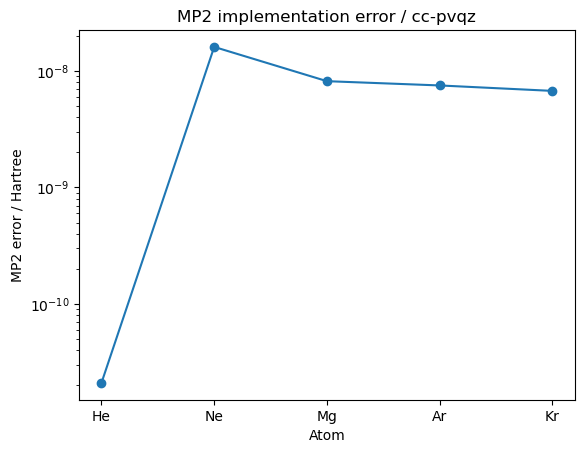

In [ ]:
plt.plot(a_names, np.array(abs_errors).real, marker="o", linestyle="-")

plt.title(f"MP2 implementation error / {basis}")
plt.yscale("log")
plt.ylabel("MP2 error / Hartree")
plt.xlabel("Atom")

plt.show()

And we can see that there is not an exact trend. 

Further thought needs to be put into this. 